<a href="https://colab.research.google.com/github/Dalbeth/Data-Science-Cohort-20/blob/main/Project-1/Transactions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Naive Bayes Classification to Predict Transactions



Deep Dive Coding Data Science Project 1

---
Kimberly Butler - March 23, 2026

## Problem Definition

The goal is to take transaction data, including both successful and unsuccessful transactions and features and predict successful transactions.  This is a supervised binary classification problem since each transaction was either successful or unsuccessful. This project will use Naive Bayes classification as the machine learning model.



## Data Collection and Source


### Data Overview

This project looks at transaction data. The data provided has the same structure as real data typically available to solve this problem. The columns of the input variables have been anonymized, so there is no intuition available to help judge which variables might be more important, so all variables need to be considered equally.

The data is available on AWS S3 at

https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv

### Imports

Import more tools that I might need.

In [1]:
from IPython.display import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

from sklearn import datasets, metrics, model_selection
from sklearn import model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

### File path and data loading


Next, data was loaded and loading was confirmed

In [2]:
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv'
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv'

In [3]:
transaction_df = pd.read_csv( url )
transaction_df

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Summarizing the information

In [4]:
transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050000 entries, 0 to 1049999
Columns: 104 entries, Unnamed: 0 to var_100
dtypes: float64(102), int64(1), object(1)
memory usage: 833.1+ MB


The data is a large dataframe with 1,050,000 rows and 104 columns.

### Describing the data

In [5]:
transaction_df.describe( include = "all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1050000.0,NaN,NaN,NaN,524999.5,303109.035663,0.0,262499.75,524999.5,787499.25,1049999.0
ID_code,1050000,1050000,train_1049983,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target,180000.0,NaN,NaN,NaN,0.100222,0.300297,0.0,0.0,0.0,0.0,1.0
var_0,180000.0,NaN,NaN,NaN,7.440715,3.021636,-2.6917,5.160325,7.35095,9.511125,16.7165
var_1,180000.0,NaN,NaN,NaN,15.870166,3.010492,6.2993,13.8304,15.9346,18.061425,26.0791
...,...,...,...,...,...,...,...,...,...,...,...
var_96,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_97,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_98,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_99,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Viewing the entire dataframe is not very informative, as there are so many variablies.  However, this view has shown a number of nulls demonstrating that the data will need to be cleaned.  Additional exploration is necessary to determine how best to clean the data.

In [6]:
transaction_df.head()

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Examining the head shows that the column names look right and that the top row does not appear to be carry over from column names

In [7]:
transaction_df.tail()

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049999,1049999,train_1049999,0.0,2.1828,12.3805,17.5654,NaN,8.1795,NaN,NaN,...,NaN,-12.1108,NaN,10.7608,NaN,NaN,NaN,NaN,NaN,14.1690


Looking at the tail shows that the final rows dont appear to be summed data

###Exploring the target data

First the target data was explored

In [8]:
transaction_df["target"].value_counts( dropna= False)

,count
target,
NaN,870000
0.0,161960
1.0,18040


In [9]:
transaction_df["target"].value_counts( normalize=True, dropna= True) * 100

,proportion
target,
0.0,89.977778
1.0,10.022222


Two main observations:

- There are many null values.  As this is the target for prediction, all null rows will be dropped.  
- This data is not balanced.  There are many more examples of unsuccessful transactions versus successful transactions.  As unbalanced data affects accuracy predictions, running the model with the two groups normalized will be worth exploring to look at the potential effect.

## Data Cleaning

In addition to the recommendations for addressing the issues with the target data described above, the features will be explored create a recommendation for dealing with issues in the features.



### Create a backup

Based on the very large number of null values in the target, I will create a backup of the data and drop the null rows from the target before further exploration

In [10]:
trans_df_bak01 = transaction_df.copy()
trans_df_bak01

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
transaction_df

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Drop nulls from target

Next, I created a cleaned dataframe with nulls dropped from target and confirmed nulls have been dropped

In [12]:
transaction_dfcleaned = transaction_df.dropna(subset=['target'])
transaction_dfcleaned

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
5,5,train_5,0.0,14.6962,18.3383,17.4788,NaN,-9.1355,NaN,NaN,...,NaN,-2.0111,NaN,-3.6166,NaN,NaN,NaN,NaN,NaN,14.4520
11,11,train_11,0.0,4.4949,14.4142,13.2219,NaN,4.9140,NaN,NaN,...,NaN,13.9424,NaN,-15.5776,NaN,NaN,NaN,NaN,NaN,14.1222
15,15,train_15,0.0,4.9657,16.2867,17.9579,NaN,0.6017,NaN,NaN,...,NaN,3.7943,NaN,5.6184,NaN,NaN,NaN,NaN,NaN,14.0619
19,19,train_19,0.0,9.4287,18.7822,10.7630,NaN,-0.7532,NaN,NaN,...,NaN,-5.6677,NaN,-1.8961,NaN,NaN,NaN,NaN,NaN,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,1049990,train_1049990,0.0,7.9632,20.4650,10.7295,NaN,2.9322,NaN,NaN,...,NaN,10.4219,NaN,-19.7158,NaN,NaN,NaN,NaN,NaN,14.0582
1049993,1049993,train_1049993,0.0,5.0862,14.4785,17.3709,NaN,-2.4732,NaN,NaN,...,NaN,-2.8052,NaN,-13.7290,NaN,NaN,NaN,NaN,NaN,14.3794
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689


In [13]:
transaction_dfcleaned["target"].value_counts( dropna= False)

,count
target,
0.0,161960
1.0,18040


A code review by Raven (Raven in space on Github) made the interesting suggestion of doing a comparison of with before and after removal of nulls.  So this was added.  The code used below to do the comparison was provided by Raven and writen by her.

In [52]:
dropped_nulls = transaction_dfcleaned["target"].value_counts( dropna= False)
original_nulls = transaction_df["target"].value_counts( dropna= False)

example_comparison = pd.concat([dropped_nulls, original_nulls], axis=1)
example_comparison

,count,count
target,,
0.0,161960.0,161960
1.0,18040.0,18040
NaN,NaN,870000


### Explore the data columns

Next, I explored the remaining columns for null values

In [14]:
transaction_dfcleaned.isna().sum().sort_values(ascending=False)*100/len(transaction_dfcleaned)

,0
var_3,100.0
var_16,100.0
var_12,100.0
var_11,100.0
var_9,100.0
...,...
var_88,0.0
var_86,0.0
var_85,0.0
var_94,0.0


###Drop null columns

There are multiple columns with all null values.  I will delete columns that are all null

In [15]:
transaction_dfcleaned = transaction_dfcleaned.dropna(axis=1, how='all')

In [16]:
transaction_dfcleaned.isna().sum().sort_values(ascending=False)*100/len(transaction_dfcleaned)

,0
Unnamed: 0,0.0
ID_code,0.0
target,0.0
var_0,0.0
var_1,0.0
var_2,0.0
var_4,0.0
var_7,0.0
var_8,0.0
var_14,0.0


###Unique identifiers

Additionally, the data was examined for likely unique identifiers and will remove these.

In [17]:
transaction_dfcleaned

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,3,train_3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,5,train_5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,11,train_11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,15,train_15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,19,train_19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,1049990,train_1049990,0.0,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,1049993,train_1049993,0.0,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


In [18]:
transaction_dfcleaned.nunique().sort_values( ascending = False )

,0
Unnamed: 0,180000
ID_code,180000
var_52,137280
var_86,134537
var_94,131746
var_20,130573
var_48,130208
var_65,129702
var_78,129453
var_92,128142


Unique identifiers are Unnamed: 0 and ID_code.  Both of these are likely unique identifiers as they have the same number of values and rows.  Based on this, they should be dropped.

In [19]:
transaction_dfcleaned = transaction_dfcleaned.drop(columns=['Unnamed: 0','ID_code'])

In [20]:
transaction_dfcleaned

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,2.2225,7.2218,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,3.4990,4.2892,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,2.8910,8.2374,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,3.2771,12.6446,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,0.0,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,3.0732,11.0135,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,0.0,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,2.4057,18.2729,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049995,1.0,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,2.4579,14.7175,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049997,0.0,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,2.5439,10.2936,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


###Backup of the cleaned data

In [21]:
trans_dfcleaned_bak02 = transaction_dfcleaned.copy()
trans_dfcleaned_bak02

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,2.2225,7.2218,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,3.4990,4.2892,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,2.8910,8.2374,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,3.2771,12.6446,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,0.0,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,3.0732,11.0135,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,0.0,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,2.4057,18.2729,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049995,1.0,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,2.4579,14.7175,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049997,0.0,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,2.5439,10.2936,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


## Exploratory Data Analysis

Next is exploratory data analysis to determine if any additional modifications of the data is necssary and to examine if the requirements for Naive Bayes are met.  





###Looking at variable data types

Will look at what data types each variable is and confirm they are formated at floats or ints

In [22]:
transaction_dfcleaned.dtypes

,0
target,float64
var_0,float64
var_1,float64
var_2,float64
var_4,float64
var_7,float64
var_8,float64
var_14,float64
var_15,float64
var_17,float64


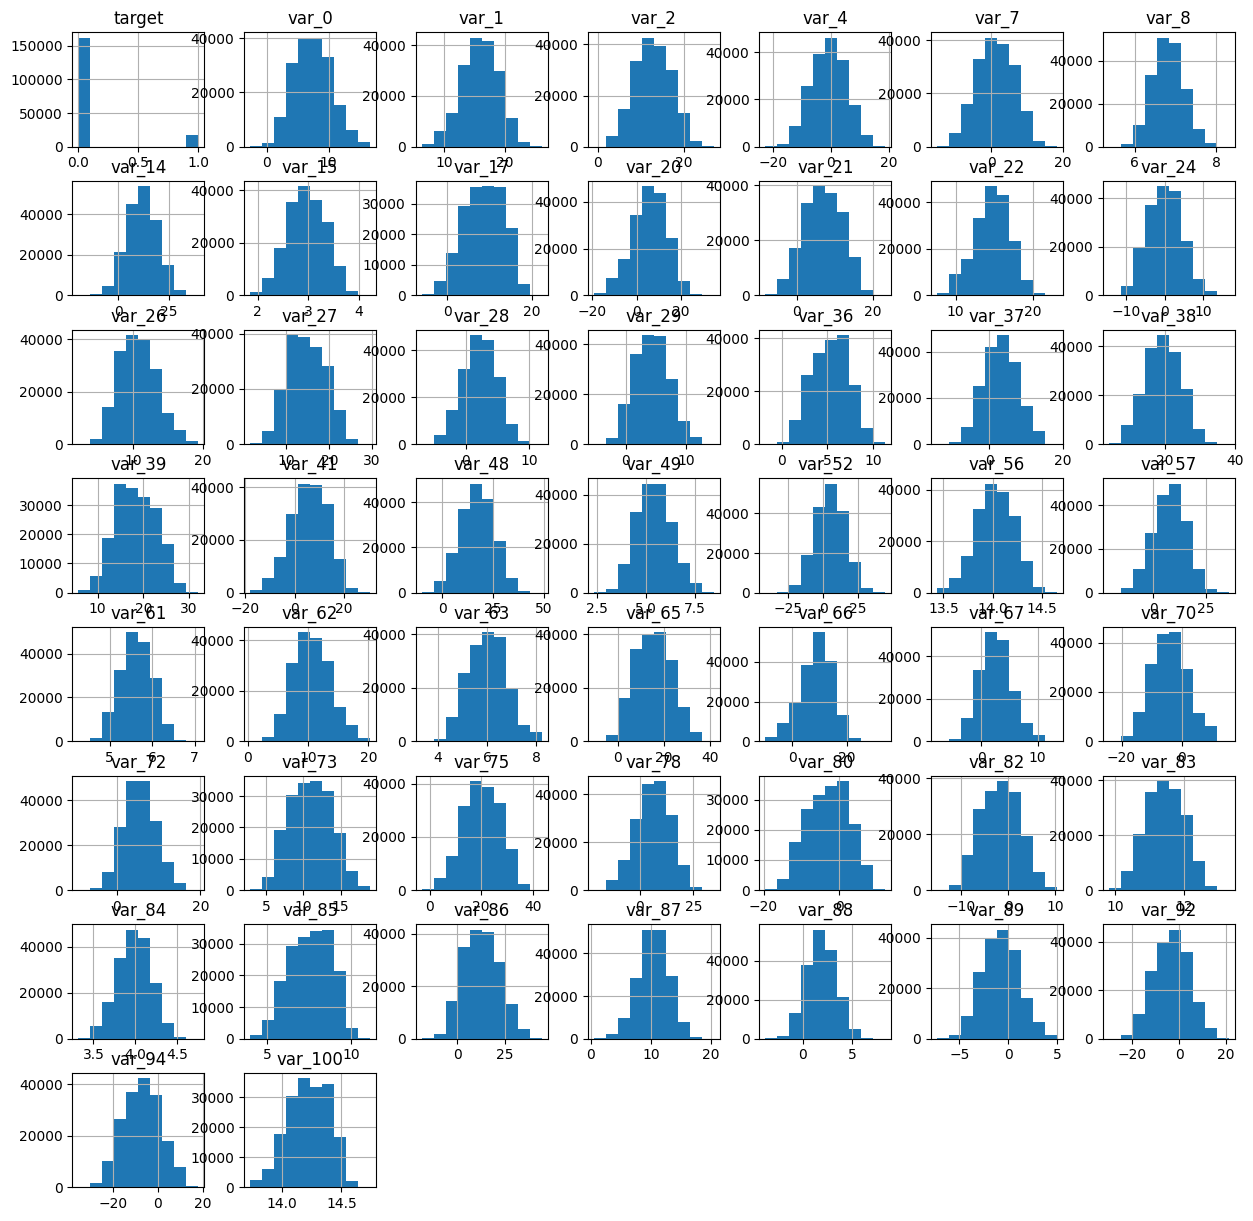

In [54]:
transaction_dfcleaned.hist(figsize=(15,15)) ;

The variables are all floats, so no conversion is needed. A quick view of the variables by histogram shows no major skews and that the data is close to normally distributed showing the features meet the requirement for gaussian naive bayes.  

### Reviewing the target data

Will first confirm there are only 2 values and that they are "1" and "0"

In [24]:
transaction_dfcleaned["target"].value_counts()

,count
target,
0.0,161960
1.0,18040


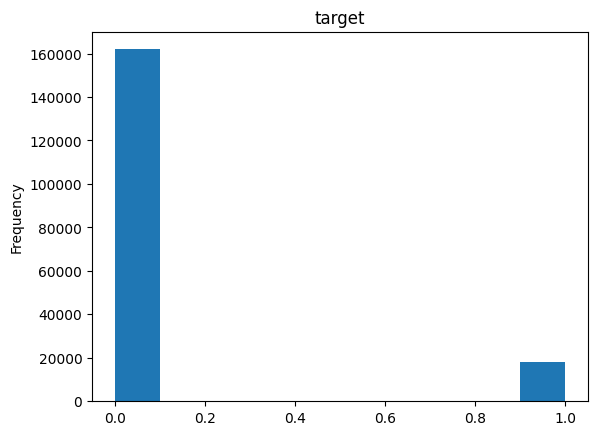

In [25]:
transaction_dfcleaned['target'].plot(kind = 'hist', title = 'target') ;

 Both the value counts and the histogram show that the data is biased, there are far fewering "1" meaning far fewer successful transactions than not.  This imbalance will affect the ability to use accuracy to evalaute the model.

###Examination of Correlations

In [26]:
corr = transaction_dfcleaned.corr()
corr

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
target,1.000000,0.045506,-0.051718,-0.046433,0.041593,-0.041987,0.052457,0.045281,-0.057373,-0.054375,...,-0.052324,-0.053733,-0.042073,0.047543,-0.063871,-0.042765,0.059306,0.040520,0.049072,-0.047005
var_0,0.045506,1.000000,-0.000892,-0.000225,-0.000269,-0.001320,0.002949,0.002901,-0.007758,-0.002799,...,-0.004960,-0.005451,-0.000716,0.004577,-0.004664,-0.001088,0.000236,0.001668,0.001837,0.001475
var_1,-0.051718,-0.000892,1.000000,0.006064,-0.000821,0.000783,-0.007127,-0.006180,-0.002585,-0.001663,...,0.004265,0.002411,0.001484,-0.003859,-0.000485,0.003141,-0.006188,0.000071,-0.003682,0.003964
var_2,-0.046433,-0.000225,0.006064,1.000000,-0.003427,-0.000108,-0.001809,-0.002786,-0.001177,0.006360,...,0.004890,0.002240,0.001980,-0.001161,0.003921,0.002087,-0.004422,-0.003418,-0.001565,0.002418
var_4,0.041593,-0.000269,-0.000821,-0.003427,1.000000,-0.002750,0.003347,0.001377,-0.004732,-0.001814,...,0.000657,-0.005267,-0.004266,-0.004179,-0.004211,-0.002330,0.000254,0.001090,-0.000468,-0.002807
var_7,-0.041987,-0.001320,0.000783,-0.000108,-0.002750,1.000000,-0.003199,-0.003588,0.002329,0.004282,...,-0.000412,0.003262,0.002574,-0.001824,0.001186,0.002811,0.001306,0.000236,-0.000568,0.004575
var_8,0.052457,0.002949,-0.007127,-0.001809,0.003347,-0.003199,1.000000,0.003472,-0.003858,-0.002727,...,-0.008394,-0.004254,-0.002446,0.001117,-0.003713,-0.003929,0.003837,0.003422,0.003204,0.000821
var_14,0.045281,0.002901,-0.006180,-0.002786,0.001377,-0.003588,0.003472,1.000000,-0.007115,-0.004249,...,-0.002214,-0.002179,-0.003054,-0.000160,-0.000504,-0.004046,0.003136,0.005715,0.001501,-0.000106
var_15,-0.057373,-0.007758,-0.002585,-0.001177,-0.004732,0.002329,-0.003858,-0.007115,1.000000,0.002467,...,0.000581,0.006633,0.004569,-0.001573,0.003251,0.003066,-0.001541,-0.003719,-0.002825,0.004247
var_17,-0.054375,-0.002799,-0.001663,0.006360,-0.001814,0.004282,-0.002727,-0.004249,0.002467,1.000000,...,0.005578,0.001237,0.000210,-0.002714,0.004149,-0.002182,-0.002642,-0.001968,-0.004100,-0.000822


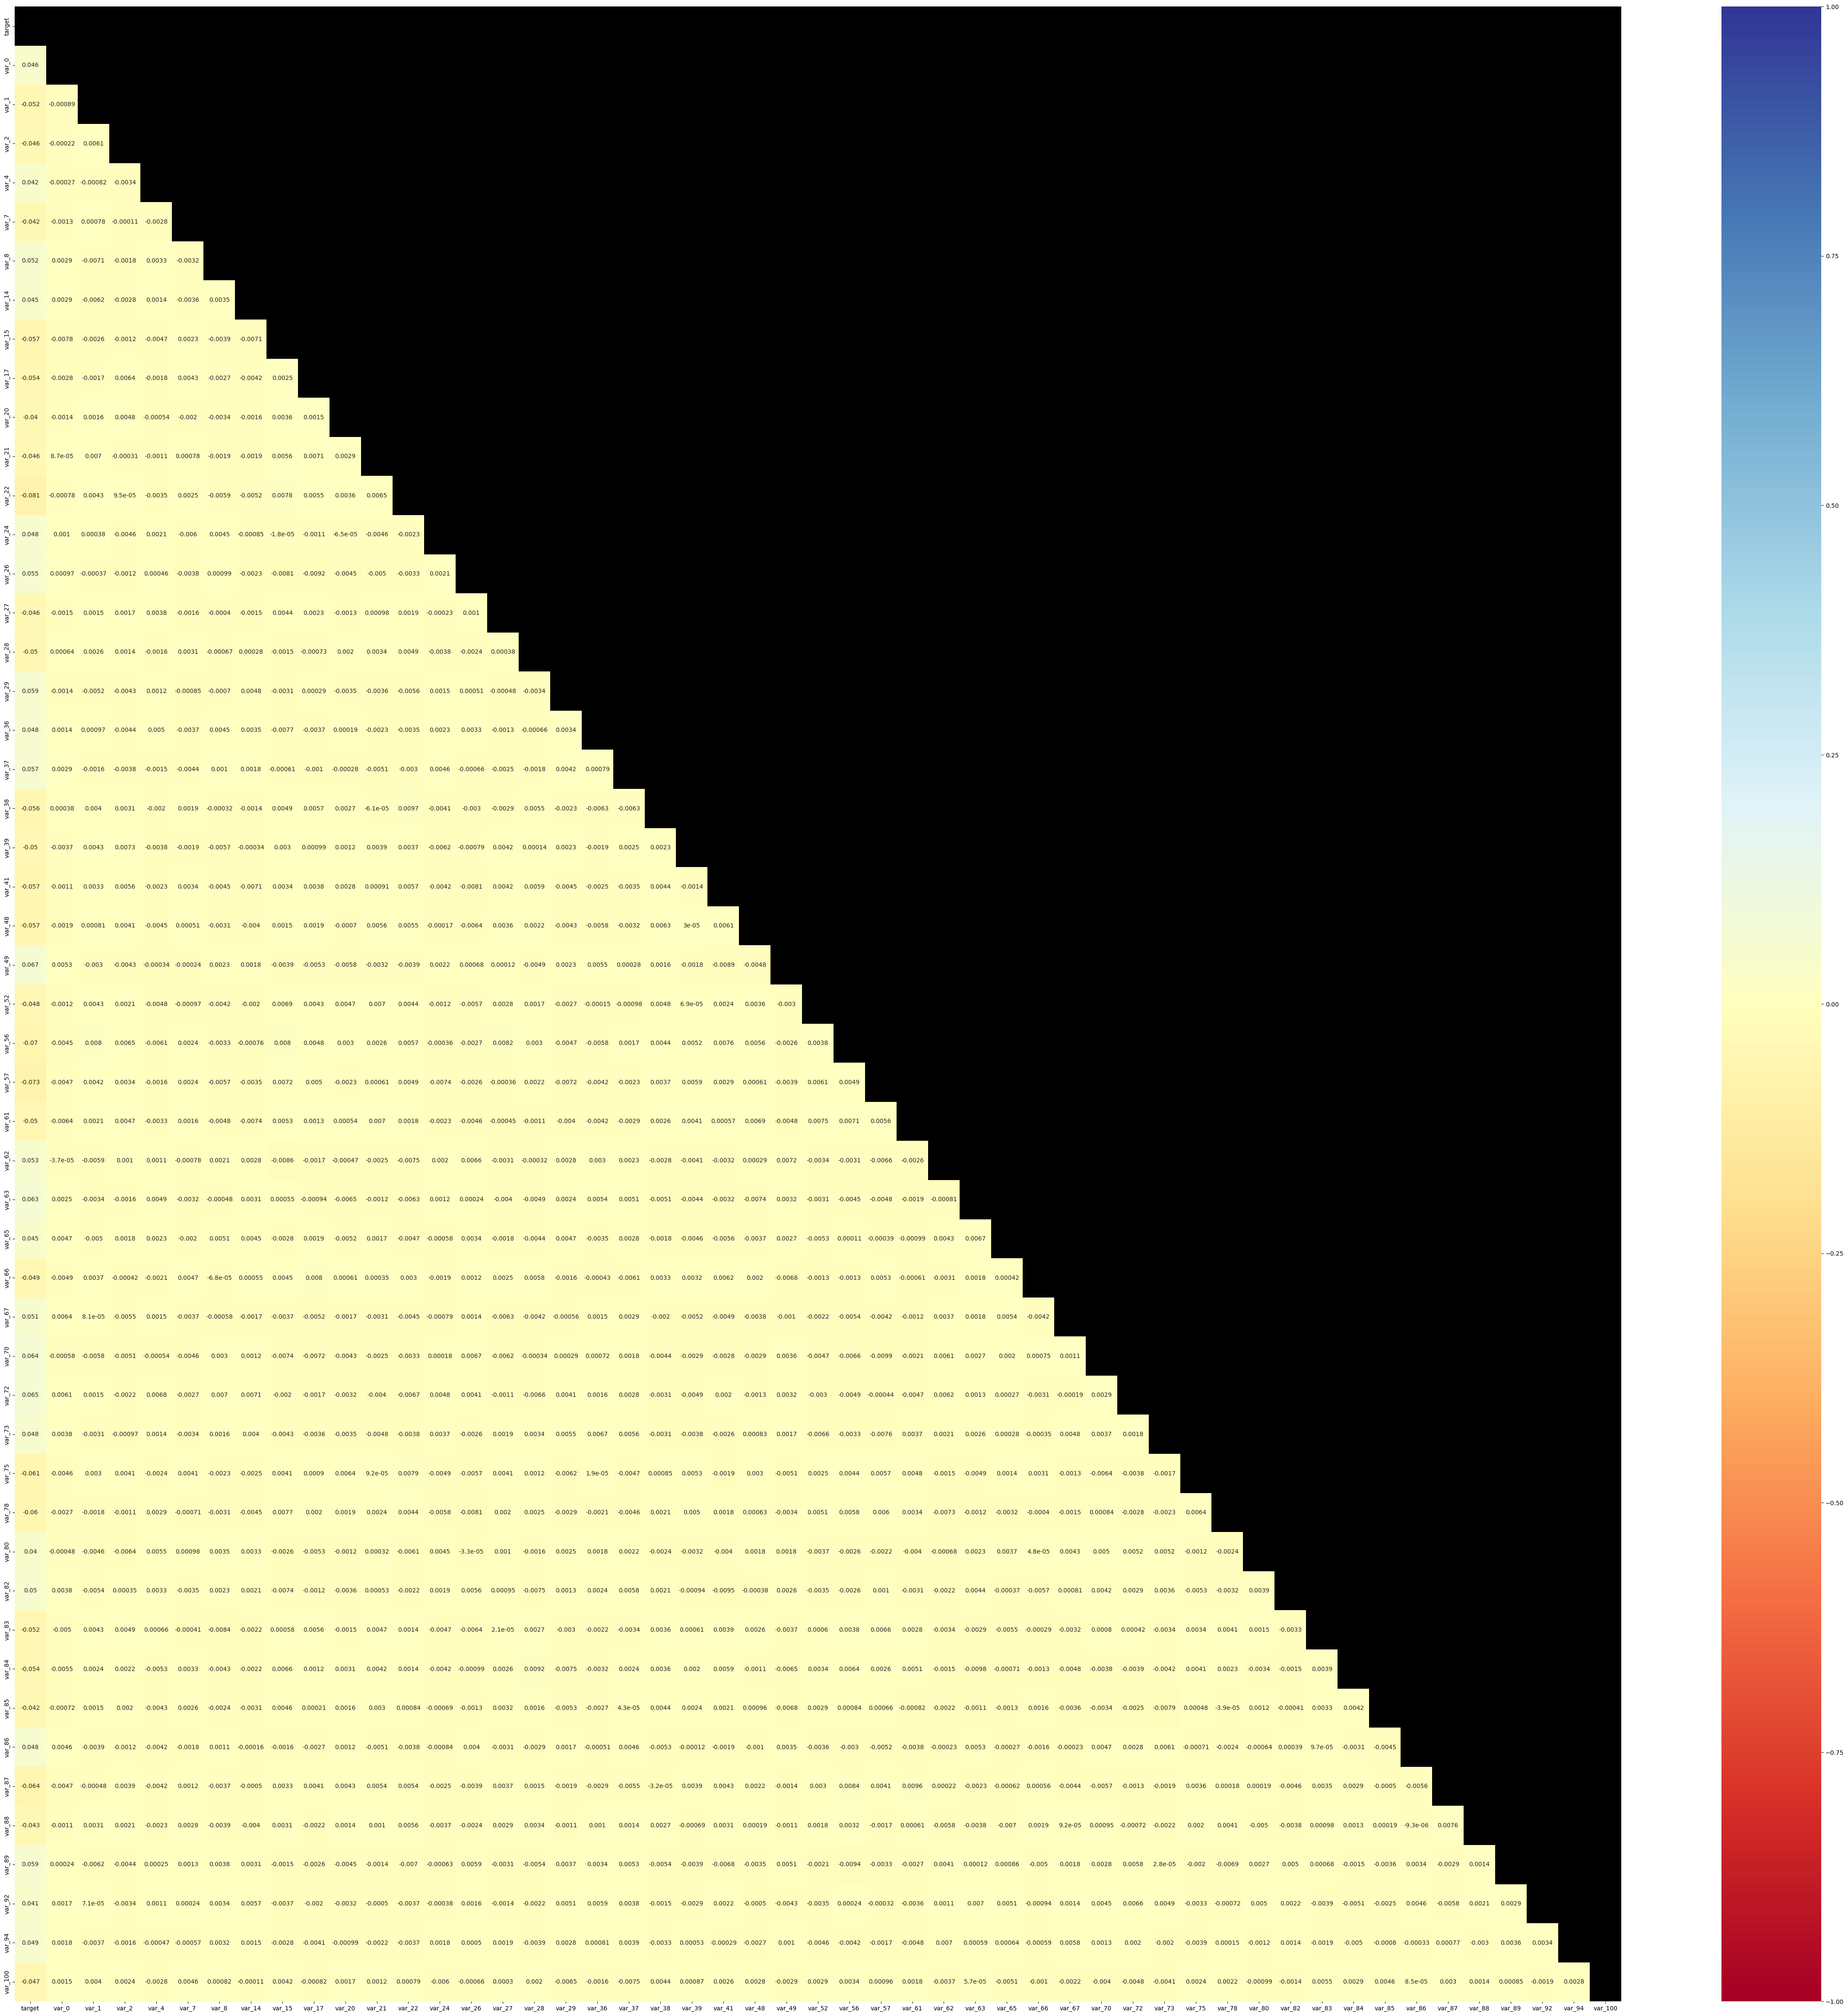

In [27]:
fig, subplot = plt.subplots(figsize=(60,60))
subplot.set_facecolor("black")
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
  corr,
  mask=mask,
  cmap='RdYlBu',
  annot = True,
  vmin = -1,
  vmax = 1,
  ax=subplot,
);

Review of the target correlation to the features does not show any strong correlation that would suggest a targeted or small feature set for prediction.  There are also no strong correlations between features.  This is important becuase correlated features would violate the rules for using Gaussian Naive Bayes for the model.

### Splitting based on successful or unsuccessful transactions

In [28]:
transpos_dfcleaned = transaction_dfcleaned[transaction_dfcleaned["target"] == 1]
transpos_dfcleaned

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
57,1.0,8.9078,12.1321,9.4707,-5.8102,0.4521,7.1264,15.6935,2.6980,4.3336,...,11.2059,4.0237,5.8905,12.4865,10.1419,2.3370,-3.1553,-12.6928,-3.0833,14.1895
125,1.0,6.2143,20.0990,23.5009,-0.8917,-3.9167,6.6863,21.4162,2.8672,6.4550,...,10.8110,3.9190,7.4971,35.7428,9.6149,2.2257,-0.5949,-9.4101,-15.6555,14.4514
151,1.0,8.9083,12.1117,18.0359,-4.9628,10.1135,6.8962,11.4553,2.6735,2.1990,...,11.6326,3.9193,5.0366,37.1453,17.0341,0.9987,-3.0163,-1.5409,-7.6389,14.1725
155,1.0,6.5612,13.9638,5.1980,12.1092,8.4874,6.4781,16.9541,2.0573,5.5008,...,11.2981,4.1316,7.2193,-1.8139,1.8190,2.5720,0.6780,6.4045,1.1754,14.1347
302,1.0,4.4616,9.7572,12.9317,7.6485,0.6382,5.8025,22.4577,3.0906,16.2501,...,11.5449,4.0001,9.0639,11.8805,9.4678,1.0561,-0.2107,9.8815,-2.9328,14.0933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049783,1.0,3.1286,15.0751,21.3962,11.3161,-10.0493,6.3525,25.4931,2.6605,7.2691,...,10.9172,4.1120,4.6540,9.1151,7.8918,2.5714,1.0304,5.2623,-0.6030,14.1993
1049818,1.0,15.2934,17.5721,5.8949,-4.0233,5.8840,7.3892,11.3932,2.7062,6.9666,...,11.1665,3.9652,7.4879,-7.9060,10.7256,0.8941,-3.5967,6.3976,0.5778,14.5067
1049978,1.0,7.4751,17.0314,5.0834,-1.5220,-2.4913,6.7953,10.7764,2.9049,2.6145,...,11.6605,3.6716,8.5965,19.2145,8.2747,4.0945,-3.0127,2.9477,-2.3696,14.4122
1049983,1.0,5.2746,14.4095,17.7709,-2.9855,-0.8515,6.5097,11.5599,2.9677,0.0507,...,11.8870,3.7776,6.9876,3.3482,9.7469,-0.3425,-2.5684,14.5286,-5.4146,14.4388


In [29]:
transneg_dfcleaned = transaction_dfcleaned[transaction_dfcleaned["target"] == 0]
transneg_dfcleaned

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,2.2225,7.2218,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,3.4990,4.2892,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,2.8910,8.2374,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,3.2771,12.6446,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049988,0.0,10.7453,13.3217,15.4001,4.0421,1.3116,6.3990,13.9387,2.9627,13.6450,...,11.6062,3.9162,9.7054,15.2405,10.6480,0.5372,0.4014,4.8258,-8.2380,14.0328
1049990,0.0,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,3.0732,11.0135,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,0.0,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,2.4057,18.2729,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049997,0.0,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,2.5439,10.2936,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


## Data Processing




###Preparing the dataset for modeling

First the data set will be split into the variables and the target

In [30]:
x = transaction_dfcleaned.drop( columns = ["target"])
y = transaction_dfcleaned["target"]

In [31]:
x

,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,var_20,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,0.5878,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,2.2225,7.2218,6.5456,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,3.4990,4.2892,18.7893,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,2.8910,8.2374,1.1400,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,3.2771,12.6446,7.8002,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,3.0732,11.0135,3.1549,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,2.4057,18.2729,3.9661,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049995,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,2.4579,14.7175,3.8858,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049997,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,2.5439,10.2936,2.0014,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


In [32]:
y

,target
3,0.0
5,0.0
11,0.0
15,0.0
19,0.0
...,...
1049990,0.0
1049993,0.0
1049995,1.0
1049997,0.0


### Single Cross Validation

Next, I tested the model with a single CV as an initial look

#### Train, Test split

In [33]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=0)
[ _.shape for _ in [x_train, x_test, y_train, y_test] ]

[(144000, 50), (36000, 50), (144000,), (36000,)]

#### Model

In [34]:
gnb = GaussianNB()

#### Fit

In [35]:
gnb.fit(x_train,y_train) ;

#### Prediction

In [36]:
y_pred = gnb.predict(x_test)
y_pred

array([0., 0., 0., ..., 0., 0., 0.])

#### Performance

We are looking at accuracy as a performance metric.
Accuracy the proportions of the number correctly predicted, which is mathematically the same as one minus the proportion incorrectly predicted.

In [37]:
(y_test - y_pred).abs().mul(-100).add(100).mean()

np.float64(91.08055555555555)

The Single CV suggests this is a very accurate prediction, 91%, so the model is worth running with multiple cross validation.

### Multiple Cross Validation

Note: the code for this was taken from the Titanic Survival Prediction done by Robert Citek and updated for my choice of coding "x" instead of "X"

#### Model and Fit

In [38]:
n = 500
results = np.zeros(n)

for i in range(n):
  ### TSS
  x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20,)
  x_train, x_test, y_train, y_test

  ### model
  gnb = GaussianNB()

  ### fit
  gnb.fit(x_train,y_train)

  ### prediction
  y_pred = gnb.predict(x_test)

  ### performance
  results[i] = 1-(y_test - y_pred).abs().mean()

#### Accuracy

In [39]:
results.mean()*100

np.float64(91.12998333333334)

The accuracy between the single CV and the mutliple CV are nearly identical. Single CV = 91.08%. Multiple CV = 91.12%.  They are essentially the same.   

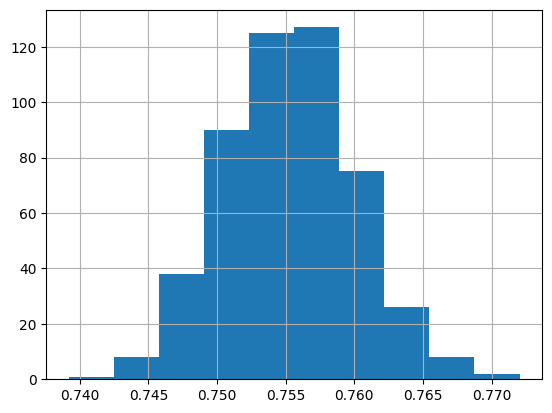

In [55]:
pd.Series(results).hist() ;

The histogram shows that the variability in the results is very small suggesting the model has very little variability between the runs.  

#### Confusion Matrix

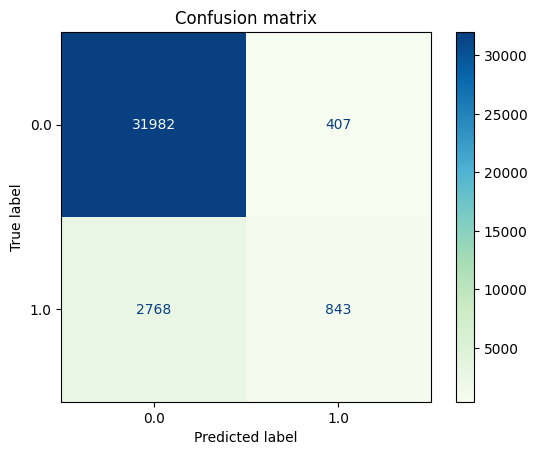

In [41]:
metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize = None,
    values_format = 'd',
    cmap = 'GnBu',
    )
plt.grid(False)
plt.title('Confusion matrix') ;

#### Metrics

Scikit learn classification report was not something I have run before.  I looked up information to understand both the syntax and to understand the output

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

In [42]:
from sklearn.metrics import classification_report
metrics.classification_report( y_test,
    y_pred,)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.92      0.99      0.95     32389
         1.0       0.67      0.23      0.35      3611

    accuracy                           0.91     36000
   macro avg       0.80      0.61      0.65     36000
weighted avg       0.90      0.91      0.89     36000



Reviewing the overall metrics show that while the accuracy is high, the precision, recall and F1-score are >90% only in the '0' group, which are those transactions are not successful. The metrics are not as good for the successful transaction group, with only precision above 65%.

#### Results and Discussion

While the accuracy was high, 91%, the dataset is very skewed with only ~10% in the purchased group.  As accuracy needs a balanced dataset, it is not a good metric for the dataset as currently used, which is highly skewed between groups.  The other metrics are good (>90%) for prediction of the non-successful transaction outcome. To better evaluate the data, a balanced data set should be explored.

### Balanced Dataset Analysis

To get a better understanding of the model's accuracy, I created a balanced dataset with equal number of purchases vs non-purchases

#### Balanced Dataset Creation

Will use the previously created positive purchase dataset but will create a new negative dataset that is matched in shape.  Will then conform that there are equal numbers of '0' and '1' in the balanced dataframe



In [43]:
transneg_dfcleaned = transaction_dfcleaned[transaction_dfcleaned["target"] == 0].sample(n = transpos_dfcleaned.shape[0] )
trans_bal = pd.concat([transneg_dfcleaned,transpos_dfcleaned])
trans_bal.shape

(36080, 51)

In [44]:
trans_bal["target"].value_counts()

,count
target,
0.0,18040
1.0,18040


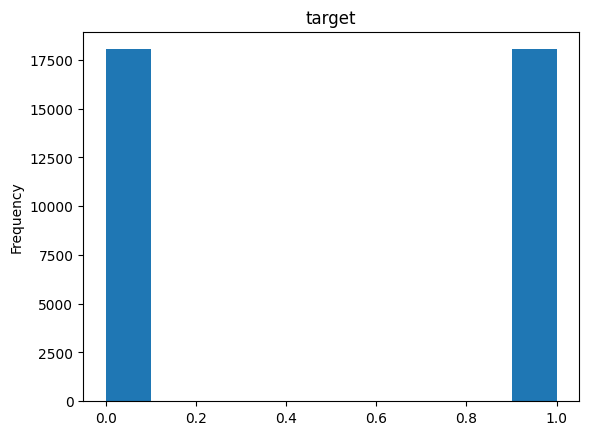

In [57]:
trans_bal['target'].plot(kind = 'hist', title = 'target') ;

In [58]:
x_bal = trans_bal.drop( columns = ["target"])
y_bal = trans_bal["target"]

In [60]:
x_bal

,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,var_20,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
157484,3.6595,19.5539,19.7176,2.3805,1.0746,6.8290,19.5368,3.2737,6.8412,8.2004,...,11.2771,4.3233,10.2126,14.9178,8.7433,2.7299,-0.4838,-12.1770,-1.4736,14.2735
1001824,11.5852,14.7661,12.7901,5.5918,-4.3891,7.2012,15.1329,3.5869,7.0654,5.4034,...,10.7846,3.7720,7.4359,8.6487,9.0622,3.8442,-0.4493,-9.4773,-2.5624,14.1791
459398,7.7739,10.2527,7.8662,-7.1074,2.0147,6.3849,21.5173,2.9254,1.1954,9.3484,...,11.2348,3.6301,6.2804,23.7486,14.5898,-0.9399,-1.6170,8.0487,-11.7521,14.0435
270299,10.3681,18.6706,13.2783,0.6105,-5.7598,6.3127,24.6315,3.3317,11.9314,6.3114,...,11.8661,4.1373,7.7637,7.4761,7.3276,3.7190,1.5878,-2.4133,-7.9118,14.1494
410708,9.5318,14.5336,9.4361,-3.7588,-7.5854,6.4748,10.7897,2.9452,5.4824,5.5066,...,11.2578,3.8254,5.7586,8.1659,7.4116,-1.2110,-3.6630,-9.1720,-5.6135,14.0942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049783,3.1286,15.0751,21.3962,11.3161,-10.0493,6.3525,25.4931,2.6605,7.2691,7.3874,...,10.9172,4.1120,4.6540,9.1151,7.8918,2.5714,1.0304,5.2623,-0.6030,14.1993
1049818,15.2934,17.5721,5.8949,-4.0233,5.8840,7.3892,11.3932,2.7062,6.9666,-6.1230,...,11.1665,3.9652,7.4879,-7.9060,10.7256,0.8941,-3.5967,6.3976,0.5778,14.5067
1049978,7.4751,17.0314,5.0834,-1.5220,-2.4913,6.7953,10.7764,2.9049,2.6145,14.3567,...,11.6605,3.6716,8.5965,19.2145,8.2747,4.0945,-3.0127,2.9477,-2.3696,14.4122
1049983,5.2746,14.4095,17.7709,-2.9855,-0.8515,6.5097,11.5599,2.9677,0.0507,6.9984,...,11.8870,3.7776,6.9876,3.3482,9.7469,-0.3425,-2.5684,14.5286,-5.4146,14.4388


In [61]:
y_bal

,target
157484,0.0
1001824,0.0
459398,0.0
270299,0.0
410708,0.0
...,...
1049783,1.0
1049818,1.0
1049978,1.0
1049983,1.0


#### Cross Validation




##### Model and Fit

In [62]:
n = 500
results = np.zeros(n)

for i in range(n):
  ### TSS
  x_bal_train, x_bal_test, y_bal_train, y_bal_test = train_test_split(x_bal, y_bal, test_size=0.20)
  x_bal_train, x_bal_test, y_bal_train, y_bal_test

  ### model
  gnb = GaussianNB()

  ### fit
  gnb.fit(x_bal_train,y_bal_train)

  ### prediction
  y_bal_pred = gnb.predict(x_bal_test)

  ### performance
  results[i] = 1-(y_bal_test - y_bal_pred).abs().mean()

##### Accuracy

In [64]:
results.mean()*100

np.float64(75.56840354767185)

##### Confusion Matrix

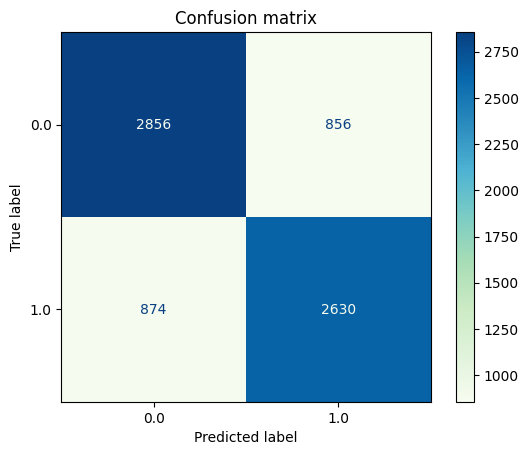

In [65]:
metrics.ConfusionMatrixDisplay.from_predictions(
    y_bal_test,
    y_bal_pred,
    normalize = None,
    values_format = 'd',
    cmap = 'GnBu',
    )
plt.grid(False)
plt.title('Confusion matrix') ;

##### Metrics

In [66]:
from sklearn.metrics import classification_report
metrics.classification_report( y_bal_test,
    y_bal_pred,)

print(classification_report(y_bal_test, y_bal_pred))

              precision    recall  f1-score   support

         0.0       0.77      0.77      0.77      3712
         1.0       0.75      0.75      0.75      3504

    accuracy                           0.76      7216
   macro avg       0.76      0.76      0.76      7216
weighted avg       0.76      0.76      0.76      7216



##### Results

The accuracy has dropped to 75.3% with the balanced data set.  However, examination of the other metrics show similar prediction values for both the successful and unsuccessful transactions highlighting the increase in successful predictions across both transaction types.  

The confusion matrix also shows close to equal accuracy in prediction for both successful and unsuccessful transactions.  

## Data Visualization

The unbalanced data set showed an accuracy of 91%, but examination of the confusion matrix this was primarily driven by the unsuccessful transactions.  Additionally, the other metrics (precision, recall and F-1 score) were only above 90% for the unsuccessful transactions

| Original data | Predicted 0 | Predicted 1 |
 - | :-: | -
| True 0 | 31991 | 429 |
| True 1 | 2788 | 792 |

By comparison the balanced dataset had a reduced accuracy of 75%, but the additional metrics showed balanced precision, recall and F-1 score of ~75% for both successful and unsuccessful transactions highlighting the increaed utility of the Gaussian Naive Bayes Model created from the balanced dataset.  This is also supported by the cofusion matrix, which showed similar accurate predictions for both successful and unsuccessful transactions

| Balanced data | Predicted 0 | Predicted 1 |
 - | :-: | -
| True 0 | 2747 | 840 |
| True 1 | 928 | 2701 |

## Communicate the Results

Conclusion:

The use of the balanced dataset developed an Gaussian Naive Bayes model with 75% accuracy in predicting transactions.  

Future work:

Increased accuracy may be possible wth other models, specifically classificationn models such as random forrest or neural networks


